# Real Estate Similarity Finder - K- Nearest Neighbour (KNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df= pd.read_csv(r"C:\Users\Nishant\Downloads\Real_Estate_Similarity.csv")

In [3]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,New_Column_1,New_Column_2,New_Column_3,New_Column_4
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,882,598,421,392
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,568,828,110,502
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,524,255,446,152
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,869,963,771,139
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,657,119,114,122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6506,635.00000,284.0,38.00,444,640.000,292.000,679.0,730.0000,354,659,935.0,24.00,267.00,933.0,964,169,345,34
6507,310.00000,381.0,183.00,736,637.000,362.000,907.0,865.0000,594,405,658.0,313.00,609.00,147.0,502,752,558,400
6508,132.00000,863.0,599.00,858,722.000,901.000,131.0,749.0000,900,906,485.0,38.00,160.00,393.0,205,726,209,370
6509,658.00000,713.0,813.00,208,146.000,448.000,515.0,203.0000,631,969,325.0,585.00,789.00,101.0,901,48,532,761


In [4]:
#CRIM- Crime rate per capita in the area
#ZN- Percentage of residential land zoned for large lots
#INDUS- Percentage of non-retail business acres
#CHAS- Whether property is near the Charles River (0 = No, 1 = Yes)
#NOX- Nitric oxide pollution concentration
#RM- Average number of rooms per dwelling
#AGE	Percentage of older houses occupied by owners
#DIS	Distance to employment centers
#RAD	Accessibility to highways
#TAX	Property tax rate
#PTRATIO	Student-teacher ratio in local schools
#B- Index related to population demographics
#LSTAT	Percentage of lower-income population
#MEDV	Median house value (Target Variable)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6511 entries, 0 to 6510
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CRIM          6511 non-null   float64
 1   ZN            6511 non-null   float64
 2   INDUS         6511 non-null   float64
 3   CHAS          6511 non-null   int64  
 4   NOX           6511 non-null   float64
 5   RM            6506 non-null   float64
 6   AGE           6511 non-null   float64
 7   DIS           6511 non-null   float64
 8   RAD           6511 non-null   int64  
 9   TAX           6511 non-null   int64  
 10  PTRATIO       6511 non-null   float64
 11  B             6511 non-null   float64
 12  LSTAT         6511 non-null   float64
 13  MEDV          6511 non-null   float64
 14  New_Column_1  6511 non-null   int64  
 15  New_Column_2  6511 non-null   int64  
 16  New_Column_3  6511 non-null   int64  
 17  New_Column_4  6511 non-null   int64  
dtypes: float64(11), int64(7)
mem

In [6]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,New_Column_1,New_Column_2,New_Column_3,New_Column_4
count,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6506.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000,6511.000000
mean,461.128321,465.997082,460.751990,459.577484,461.751111,465.699281,468.078774,454.125720,462.281370,497.965597,462.745277,484.804340,458.155806,465.327999,498.170481,499.019813,495.344340,495.517432
std,308.121741,307.176944,304.761437,307.164230,308.486963,309.023117,298.868480,304.446132,306.023926,283.582054,305.153297,282.986343,304.780772,307.438132,288.075386,288.020359,286.039275,288.171633
min,0.006320,0.000000,0.460000,0.000000,0.385000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.320000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,185.000000,192.000000,191.000000,190.000000,185.500000,186.000000,195.000000,182.000000,189.000000,264.000000,189.000000,254.000000,187.000000,183.000000,245.000000,248.000000,254.000000,242.000000
50%,459.000000,461.000000,453.000000,457.000000,457.000000,463.000000,461.000000,456.000000,455.000000,485.000000,457.000000,446.000000,446.000000,466.000000,502.000000,494.000000,487.000000,499.000000
75%,729.500000,738.000000,726.000000,727.000000,729.500000,738.000000,730.000000,717.000000,733.000000,742.000000,724.000000,733.500000,721.000000,731.500000,749.000000,745.500000,743.000000,740.000000
max,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000


In [7]:
df.isnull().sum()

CRIM            0
ZN              0
INDUS           0
CHAS            0
NOX             0
RM              5
AGE             0
DIS             0
RAD             0
TAX             0
PTRATIO         0
B               0
LSTAT           0
MEDV            0
New_Column_1    0
New_Column_2    0
New_Column_3    0
New_Column_4    0
dtype: int64

In [8]:
df.columns = [
    'Property_ID',
    'Crime_Rate',
    'Residential_Land',
    'Business_Area',
    'Near_River',
    'Pollution_Level',
    'Average_Rooms',
    'House_Age',
    'Employment_Distance',
    'Highway_Access',
    'Property_Tax',
    'Student_Teacher_Ratio',
    'Population_Index',
    'Low_Income_Percentage',
    'Median_House_Value',
    'Area_Code',
    'Building_Age',
    'Property_Score'
]

df.head()

,Property_ID,Crime_Rate,Residential_Land,Business_Area,Near_River,Pollution_Level,Average_Rooms,House_Age,Employment_Distance,Highway_Access,Property_Tax,Student_Teacher_Ratio,Population_Index,Low_Income_Percentage,Median_House_Value,Area_Code,Building_Age,Property_Score
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,882,598,421,392
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,568,828,110,502
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,524,255,446,152
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,869,963,771,139
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,657,119,114,122


In [9]:
# Fill numerical columns with median

for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
print(df.isnull().sum())

Property_ID              0
Crime_Rate               0
Residential_Land         0
Business_Area            0
Near_River               0
Pollution_Level          0
Average_Rooms            0
House_Age                0
Employment_Distance      0
Highway_Access           0
Property_Tax             0
Student_Teacher_Ratio    0
Population_Index         0
Low_Income_Percentage    0
Median_House_Value       0
Area_Code                0
Building_Age             0
Property_Score           0
dtype: int64


C:\Users\Nishant\AppData\Local\Temp\ipykernel_24888\821839782.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [10]:
print("Duplicate Rows :", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate Rows : 0


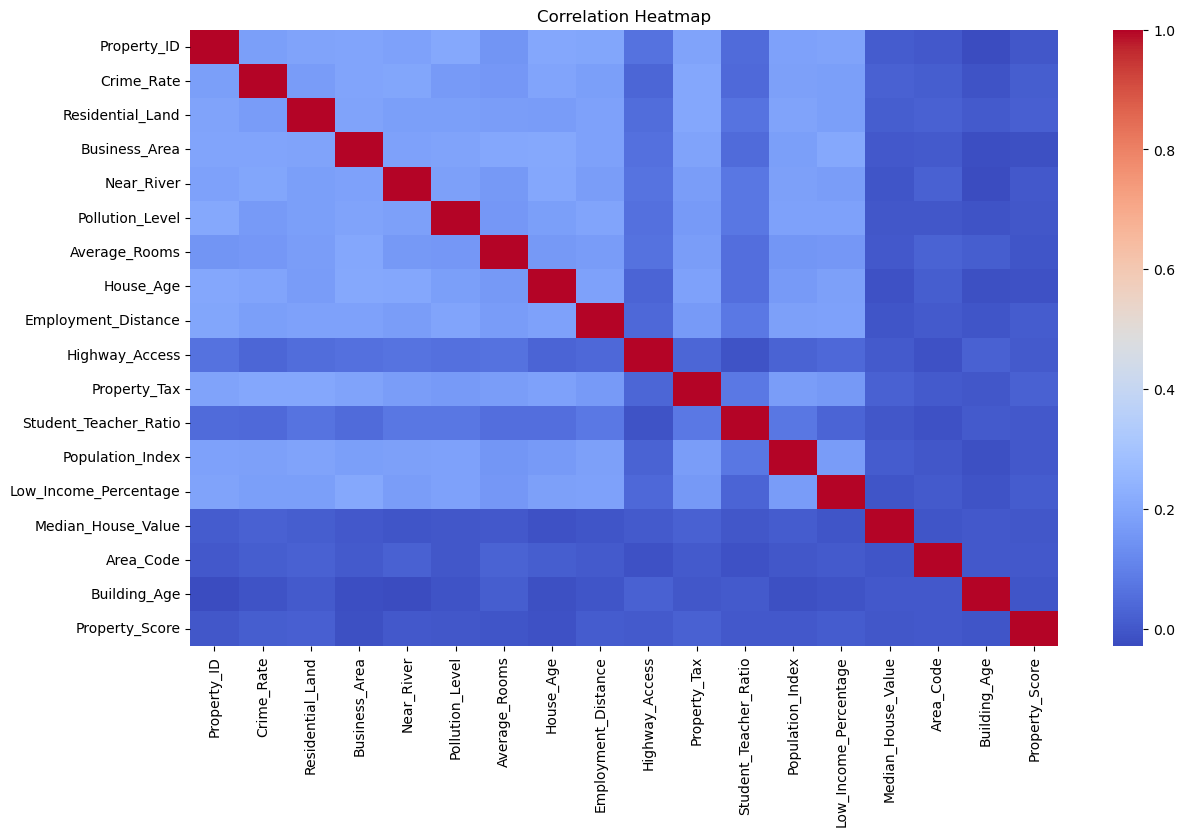

In [11]:
plt.figure(figsize=(14,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

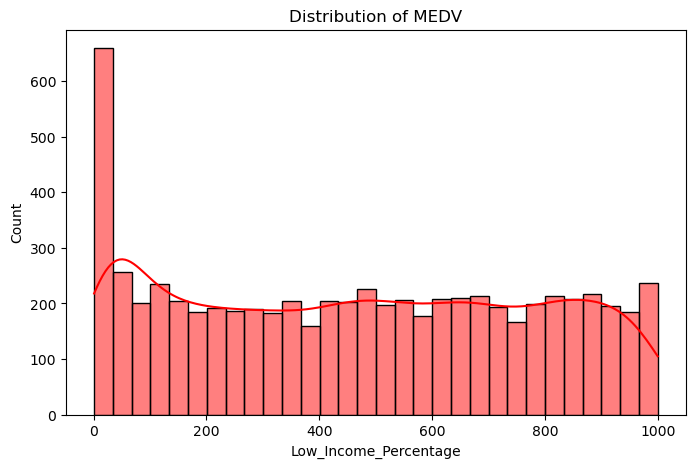

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Low_Income_Percentage'], bins=30,color='Red', kde=True)
plt.title("Distribution of MEDV")
plt.show()

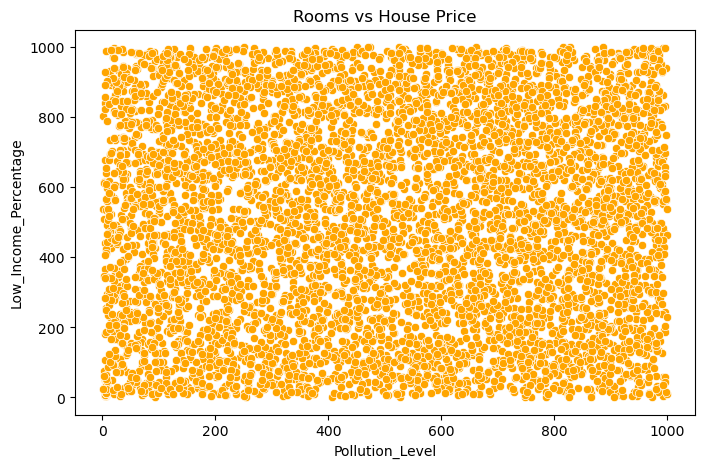

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Pollution_Level', y='Low_Income_Percentage', data=df,color="Orange")
plt.title("Rooms vs House Price")
plt.show()

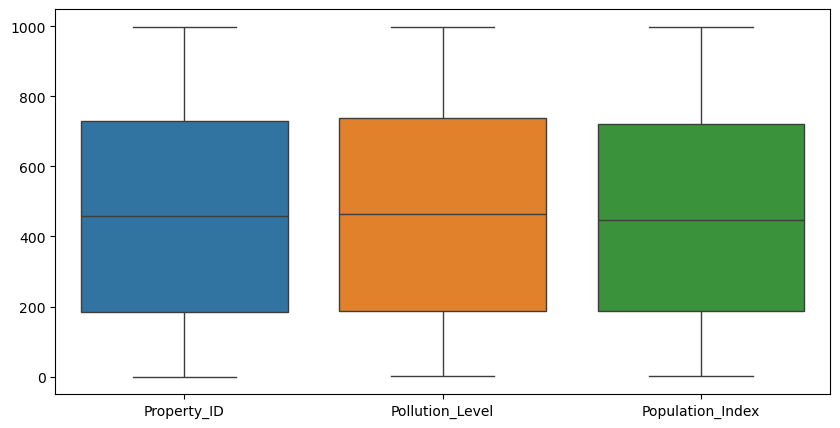

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[['Property_ID','Pollution_Level','Population_Index']])
plt.show()

In [15]:
y = df['Low_Income_Percentage']

In [16]:
X = df.drop('Low_Income_Percentage', axis=1)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred = knn.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 239.86882578664623
MSE : 90123.63718188796
RMSE : 300.2059912491554
R2 Score : 0.06708349921233503


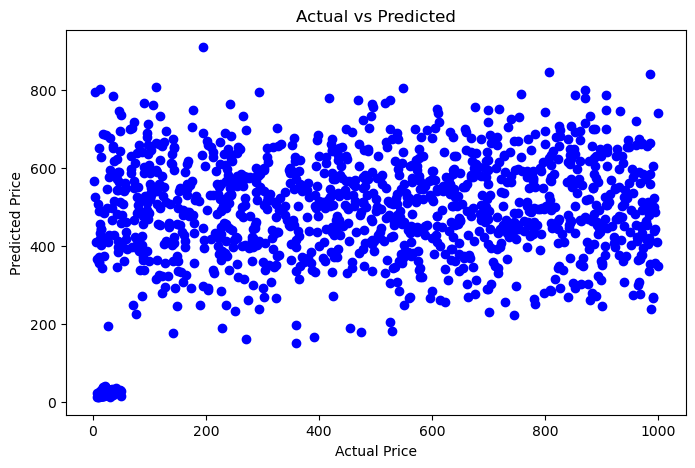

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color="blue")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

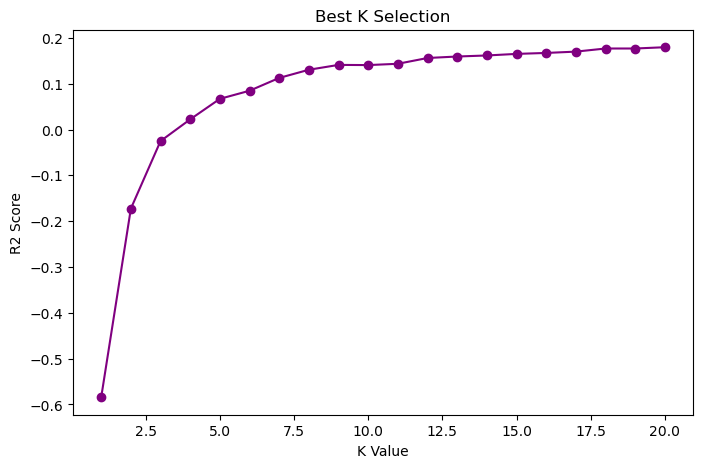

In [23]:
scores = []

for k in range(1,21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(r2_score(y_test, pred))
    
plt.figure(figsize=(8,5))
plt.plot(range(1,21), scores,color="Purple",marker='o')
plt.xlabel("K Value")
plt.ylabel("R2 Score")
plt.title("Best K Selection")
plt.show()